# Notebook 1 — Data Profiling & Tier-1 Exploratory Data Analysis

**Project:** E-Commerce Retail & Fulfillment Analytics — an Amazon Retail / Operations analog
built on the Olist Brazilian e-commerce dataset (Sep-2016 – Oct-2018).

**Dataset scale:** 99,441 orders · 96,096 unique customers · 3,095 sellers · 32,951 products
across 74 mapped categories · 112,650 order line items · 103,886 payment records.

## Where this fits in the project

The SQL analytics catalog (`sql/analytics/01–04`, 27 queries) answers a set of
*pre-defined* business questions with production-style CTE/window-function
queries — the kind of recurring, scheduled reporting an analyst would ship as
dashboards. **This notebook is the open-ended exploratory work that comes
*before* those questions are even known**: profile the raw shape and quality
of the data, characterize every key distribution, hunt for outliers and
anomalies, and map the bivariate/multivariate relationships that motivate the
deeper-dive notebooks that follow:

| # | Notebook | Focus |
|---|---|---|
| 1 | `01_data_profiling_and_eda.ipynb` (this notebook) | Profiling, missingness, univariate/bivariate/multivariate EDA |
| 2 | `02_time_series_decomposition.ipynb` | Trend/seasonality decomposition of orders & revenue |
| 3 | `03_geospatial_analysis.ipynb` | State-level choropleth — revenue, delivery time, satisfaction |
| 4 | `04_hypothesis_testing.ipynb` | Formal statistical tests — delivery delay vs. review score, category/region effects |
| 5 | `05_customer_segmentation.ipynb` | RFM + K-means clustering, segment profiles |
| 6 | `06_predictive_modeling.ipynb` | Logistic regression — late-delivery & low-review risk |

## Roadmap for this notebook

1. Data Overview & Loading
2. Missingness Profile
3. Categorical Profile (Cardinality & Distributions)
4. Univariate Analysis — Numeric Distributions
5. Outlier Detection
6. Bivariate Analysis
7. Multivariate Analysis
8. Key Findings Summary

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from etl.db import get_engine

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

engine = get_engine()
print("Connected to:", engine.url.render_as_string(hide_password=True))

Connected to: postgresql+psycopg2://akhileshvangala@localhost:5432/olist_analytics


## 1. Data Overview & Loading

We load all six `marts` tables into memory — at this scale (largest table is
112,650 rows) this is well within pandas' comfort zone and avoids round-tripping
to Postgres for every exploratory query in this notebook.

In [2]:
fact_orders   = pd.read_sql("SELECT * FROM marts.fact_orders", engine)
fact_items    = pd.read_sql("SELECT * FROM marts.fact_order_items", engine)
fact_payments = pd.read_sql("SELECT * FROM marts.fact_order_payments", engine)
dim_product   = pd.read_sql("SELECT * FROM marts.dim_product", engine)
dim_customer  = pd.read_sql("SELECT * FROM marts.dim_customer", engine)
dim_seller    = pd.read_sql("SELECT * FROM marts.dim_seller", engine)

shapes = pd.DataFrame({
    "table": ["fact_orders", "fact_order_items", "fact_order_payments",
              "dim_product", "dim_customer", "dim_seller"],
    "grain": ["1 row / order", "1 row / order line item",
              "1 row / (order, payment installment-method)",
              "1 row / product", "1 row / unique customer (customer_unique_id)",
              "1 row / seller"],
    "n_rows": [len(fact_orders), len(fact_items), len(fact_payments),
               len(dim_product), len(dim_customer), len(dim_seller)],
    "n_cols": [fact_orders.shape[1], fact_items.shape[1], fact_payments.shape[1],
               dim_product.shape[1], dim_customer.shape[1], dim_seller.shape[1]],
})
shapes

,table,grain,n_rows,n_cols
0,fact_orders,1 row / order,99441,35
1,fact_order_items,1 row / order line item,112650,9
2,fact_order_payments,"1 row / (order, payment installment-method)",103886,6
3,dim_product,1 row / product,32951,12
4,dim_customer,1 row / unique customer (customer_unique_id),96096,9
5,dim_seller,1 row / seller,3095,6


**Row-count sanity check (ties to `docs/data_quality_report.md`):**

- `fact_orders` = 99,441 rows = `raw.orders` row count exactly (1:1 grain, no fan-out).
- `fact_order_items` = 112,650 rows = `raw.order_items` exactly (pass-through fact).
- `fact_order_payments` = 103,886 rows = `raw.order_payments` exactly.
- `dim_customer` = 96,096 < 99,441 `customer_id`s — the expected deduplication down to
  the *person* grain (`customer_unique_id`); 3,345 people placed more than one order.
- `dim_product` = 32,951 = `raw.products` exactly; `dim_seller` = 3,095 = `raw.sellers` exactly.

All counts reconcile with the automated DQ checks (32/32 PASS) — we're working with a
clean, fully-reconciled star schema.

In [3]:
# Column catalog for fact_orders, grouped by role - a "data dictionary at a glance"
col_groups = {
    "Identifiers / dims": ["order_id", "customer_unique_id", "customer_zip_code_prefix",
                            "customer_state", "order_status", "primary_payment_type"],
    "Timestamps": ["order_purchase_timestamp", "order_approved_at",
                   "order_delivered_carrier_date", "order_delivered_customer_date",
                   "order_estimated_delivery_date"],
    "Order-level aggregates": ["n_items", "n_distinct_products", "n_distinct_sellers",
                                "items_price_total", "freight_value_total", "order_total_value",
                                "payment_value_total", "max_installments", "n_payment_types"],
    "Review": ["review_score", "has_review"],
    "Fulfillment timing (derived)": ["approval_hours", "carrier_handoff_days",
                                      "shipping_transit_days", "actual_delivery_days",
                                      "estimated_delivery_days", "delivery_delay_days"],
    "DQ / status flags": ["is_delivered", "is_late", "is_canceled",
                           "dq_delivered_missing_date", "dq_carrier_before_approval",
                           "dq_delivered_before_carrier"],
}

rows = []
for group, cols in col_groups.items():
    for c in cols:
        rows.append({"group": group, "column": c, "dtype": str(fact_orders[c].dtype)})
catalog = pd.DataFrame(rows)
print(f"fact_orders: {len(catalog)} of {fact_orders.shape[1]} columns documented")
catalog

fact_orders: 34 of 35 columns documented


,group,column,dtype
0,Identifiers / dims,order_id,str
1,Identifiers / dims,customer_unique_id,str
2,Identifiers / dims,customer_zip_code_prefix,str
3,Identifiers / dims,customer_state,str
4,Identifiers / dims,order_status,str
5,Identifiers / dims,primary_payment_type,str
6,Timestamps,order_purchase_timestamp,datetime64[us]
7,Timestamps,order_approved_at,datetime64[us]
8,Timestamps,order_delivered_carrier_date,datetime64[us]
9,Timestamps,order_delivered_customer_date,datetime64[us]


## 2. Missingness Profile

A senior-level EDA never treats `NaN` as noise to drop blindly — every missing
value has a *cause*, and the cause determines whether it's safe to ignore,
needs an explicit flag (which the marts layer already provides via
`dq_*` columns), or signals a real upstream data issue.

In [4]:
miss = fact_orders.isna().sum()
miss_pct = 100 * miss / len(fact_orders)
miss_df = (pd.DataFrame({"n_missing": miss, "pct_missing": miss_pct})
           .query("n_missing > 0")
           .sort_values("pct_missing", ascending=False))
miss_df

,n_missing,pct_missing
shipping_transit_days,2966,2.98
order_delivered_customer_date,2965,2.98
actual_delivery_days,2965,2.98
delivery_delay_days,2965,2.98
carrier_handoff_days,1797,1.81
order_delivered_carrier_date,1783,1.79
n_distinct_products,775,0.78
n_distinct_sellers,775,0.78
review_score,768,0.77
order_approved_at,160,0.16


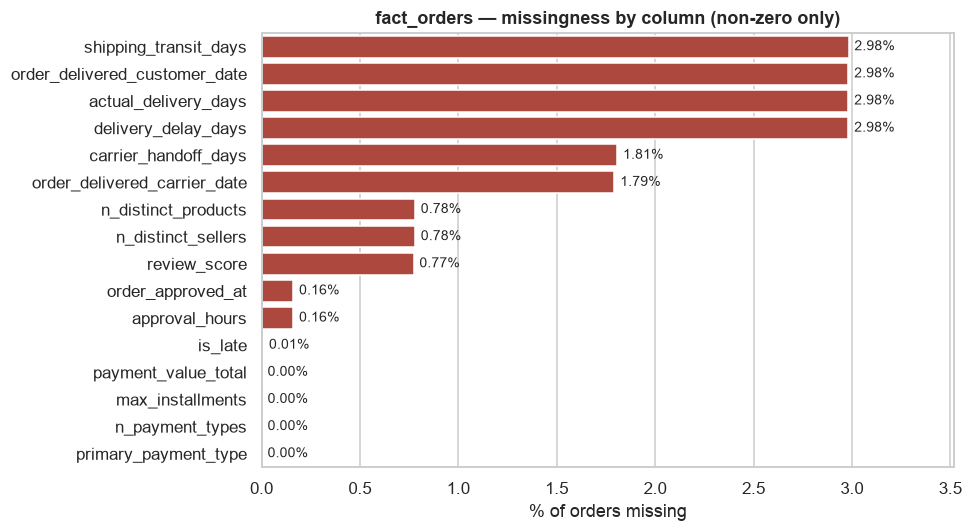

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=miss_df["pct_missing"], y=miss_df.index, ax=ax, color="#c0392b")
ax.set_xlabel("% of orders missing")
ax.set_ylabel("")
ax.set_title("fact_orders — missingness by column (non-zero only)")
for i, v in enumerate(miss_df["pct_missing"]):
    ax.text(v + 0.03, i, f"{v:.2f}%", va="center", fontsize=9)
ax.set_xlim(0, miss_df["pct_missing"].max() * 1.18)
plt.tight_layout()
plt.show()

### Root-cause verification

Rather than assert explanations, we cross-tabulate each missing-value pattern
against `order_status` (and other columns) to *prove* the cause.

In [6]:
print("order_delivered_customer_date missing, by order_status:")
print(fact_orders.loc[fact_orders["order_delivered_customer_date"].isna(), "order_status"]
      .value_counts().to_string())

print("\norder_delivered_carrier_date missing, by order_status:")
print(fact_orders.loc[fact_orders["order_delivered_carrier_date"].isna(), "order_status"]
      .value_counts().to_string())

print("\nn_distinct_products / n_distinct_sellers missing, by order_status:")
print(fact_orders.loc[fact_orders["n_distinct_products"].isna(), "order_status"]
      .value_counts().to_string())

print("\norder_approved_at missing, by order_status:")
print(fact_orders.loc[fact_orders["order_approved_at"].isna(), "order_status"]
      .value_counts().to_string())

print("\nOrder(s) with no payment record at all:")
print(fact_orders.loc[fact_orders["payment_value_total"].isna(),
      ["order_id", "order_status", "order_total_value", "n_items", "order_purchase_date"]]
      .to_string(index=False))

order_delivered_customer_date missing, by order_status:
order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2

order_delivered_carrier_date missing, by order_status:
order_status
unavailable    609
canceled       550
invoiced       314
processing     301
created          5
delivered        2
approved         2

n_distinct_products / n_distinct_sellers missing, by order_status:
order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1

order_approved_at missing, by order_status:
order_status
canceled     141
delivered     14
created        5

Order(s) with no payment record at all:
                        order_id order_status  order_total_value  n_items order_purchase_date
bfbd0f9bdef84302105ad712db648a6c    delivered             143.46        3          2016-09-15


### Interpretation — every missingness pattern has a clean explanation

| Column(s) | % missing | Root cause |
|---|---|---|
| `order_delivered_customer_date`, `actual_delivery_days`, `delivery_delay_days`, `shipping_transit_days` | 2.98% (2,965–2,966) | Dominated by orders that **haven't reached "delivered"** yet (`shipped` 1,107 + `canceled` 619 + `unavailable` 609 + `invoiced` 314 + `processing` 301 + `created` 5 + `approved` 2 = 2,957), plus **8 orders with `order_status='delivered'` but no recorded delivery scan** — exactly the `dq_delivered_missing_date` flag (8 rows, 0.01%) documented in the DQ report. |
| `order_delivered_carrier_date`, `carrier_handoff_days` | 1.79–1.81% (1,783–1,797) | Same logic one stage earlier: orders that never reached the carrier (`unavailable` 609 + `canceled` 550 + `invoiced` 314 + `processing` 301 + `created` 5), plus 2 `delivered` and 2 `approved` edge cases with a missing carrier scan but a recorded customer delivery — an inconsistent-but-rare source timestamp gap. |
| `n_distinct_products`, `n_distinct_sellers` | 0.78% (775) | Orders with **zero line items** (`LEFT JOIN` to `fact_order_items` finds nothing) — 603 `unavailable` + 164 `canceled` + 5 `created` + 2 `invoiced` + 1 `shipped`. `items_price_total`/`freight_value_total`/`order_total_value` are `COALESCE`d to 0 for these, but the *count* fields stay `NULL` (you can't have "zero distinct products" be a meaningful count vs. "unknown") — correct, intentional design. |
| `review_score`, `has_review=False` | 0.77% (768) | No review was ever submitted for that order. **Exactly matches** the DQ report's "0.77% (768 orders)" completeness INFO check — a consistency check passed. |
| `order_approved_at`, `approval_hours` | 0.16% (160) | Orders that were **never approved**: 141 `canceled` before payment cleared, 14 `delivered` (approval timestamp gap — rare source anomaly), 5 `created` (abandoned at checkout). |
| `is_late` | 0.01% (8) | `is_late = (status='delivered' AND delivered_customer_date > estimated_delivery_date)`. When `delivered_customer_date IS NULL`, the comparison evaluates to `NULL` in SQL three-valued logic — these are the **same 8 `dq_delivered_missing_date` orders** above. Pandas correctly preserves this as `NaN`/`None` rather than silently coercing to `False`. |
| `payment_value_total`, `max_installments`, `n_payment_types`, `primary_payment_type` | 0.00% (1 order) | A **single** `delivered` order (`bfbd0f9bdef84302105ad712db648a6c`, purchased 2016-09-15 — the platform's very first week) has **no payment record at all**. `order_total_value` ($143.46, 3 items) is still computed from `fact_order_items`, so this order is *not* a phantom — just a payments-table gap from the platform's pilot period. |

**Conclusion:** zero unexplained missingness. Every gap is either (a) a structural
consequence of order lifecycle stage, (b) already flagged by a `dq_*` column for
downstream exclusion, or (c) a single isolated pilot-period record. No imputation
is needed anywhere in this dataset — every analytics query simply filters on the
relevant stage/flag, as the SQL catalog already does.

In [7]:
miss2 = dim_product.isna().sum()
miss2_pct = 100 * miss2 / len(dim_product)
miss2_df = (pd.DataFrame({"n_missing": miss2, "pct_missing": miss2_pct})
            .query("n_missing > 0")
            .sort_values("pct_missing", ascending=False))
print(f"'unknown' (unmapped) category rows: {(dim_product['product_category_name_english'] == 'unknown').sum()}")
miss2_df

'unknown' (unmapped) category rows: 610


,n_missing,pct_missing
product_name_length,610,1.85
product_description_length,610,1.85
product_photos_qty,610,1.85
product_weight_g,2,0.01
product_length_cm,2,0.01
product_height_cm,2,0.01
product_width_cm,2,0.01
product_volume_cm3,2,0.01


**`dim_product` missingness:**

- `product_name_length`, `product_description_length`, `product_photos_qty` —
  missing for 610 products (1.85%). These are the **same 610 products** with no
  category mapping (`product_category_name_english = 'unknown'`, handled in
  staging via `dq_category_missing`) — likely listings that were deleted/deactivated
  before the source extract, leaving only the `product_id` and physical dimensions.
- `product_weight_g/length/height/width/volume_cm3` — missing for just 2 products
  (0.01%), immaterial.

None of these gaps block any analysis in this project: category-based queries
either fall into the explicit `'unknown'` bucket (visible and excludable) or are
weighted by revenue, where these 610 products contribute a negligible share.

## 3. Categorical Profile — Cardinality & Distributions

Before diving into numeric distributions, we map out the shape of the
categorical "skeleton" of the dataset: order lifecycle outcomes, payment
method mix, customer geography, and product category mix.

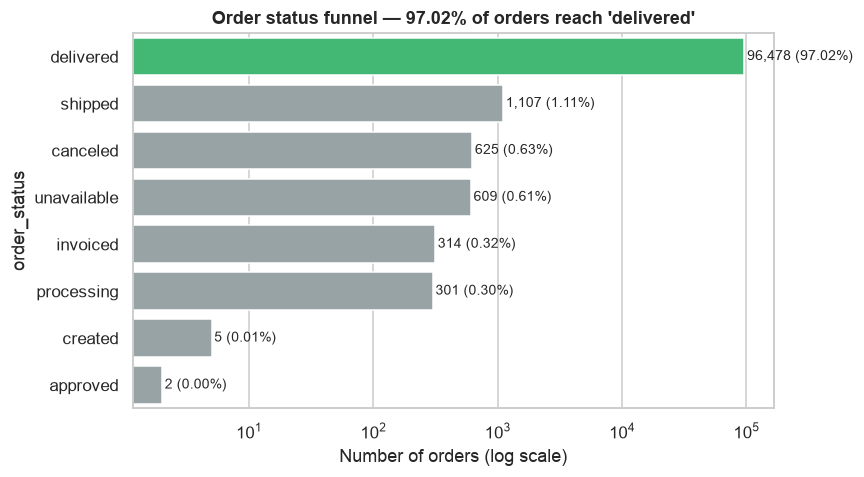

In [8]:
status_counts = fact_orders["order_status"].value_counts()
status_pct = 100 * status_counts / status_counts.sum()

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#2ecc71" if s == "delivered" else "#95a5a6" for s in status_counts.index]
sns.barplot(x=status_counts.values, y=status_counts.index, ax=ax, palette=colors, hue=status_counts.index, legend=False)
ax.set_xscale("log")
ax.set_xlabel("Number of orders (log scale)")
ax.set_title(f"Order status funnel — {status_pct['delivered']:.2f}% of orders reach 'delivered'")
for i, (v, p) in enumerate(zip(status_counts.values, status_pct.values)):
    ax.text(v * 1.05, i, f"{v:,} ({p:.2f}%)", va="center", fontsize=9)
plt.tight_layout()
plt.show()

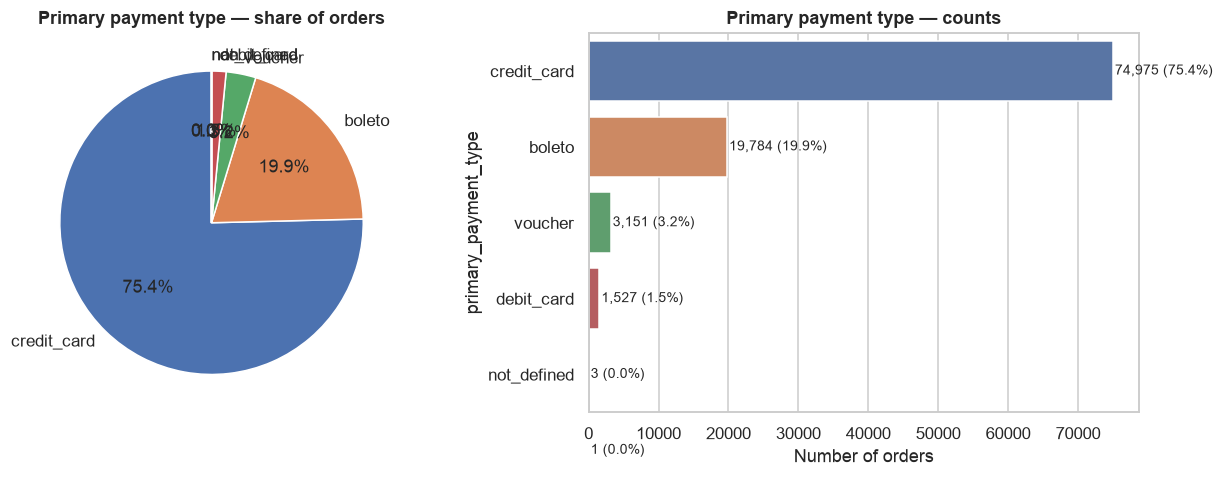

In [9]:
pay_counts = fact_orders["primary_payment_type"].value_counts(dropna=False)
pay_pct = 100 * pay_counts / pay_counts.sum()

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].pie(pay_counts.values, labels=pay_counts.index.astype(str), autopct="%1.1f%%",
          startangle=90, colors=sns.color_palette("deep", len(pay_counts)))
ax[0].set_title("Primary payment type — share of orders")

sns.barplot(x=pay_counts.values, y=pay_counts.index.astype(str), ax=ax[1],
            hue=pay_counts.index.astype(str), legend=False, palette="deep")
ax[1].set_xlabel("Number of orders")
ax[1].set_title("Primary payment type — counts")
for i, v in enumerate(pay_counts.values):
    ax[1].text(v + 300, i, f"{v:,} ({pay_pct.values[i]:.1f}%)", va="center", fontsize=9)

plt.tight_layout()
plt.show()

**Payment mix:** credit card dominates at 75.4% of orders, followed by `boleto`
(Brazilian bank-slip payment, 19.9%) — a payment method with **no direct US
equivalent**, reflecting Brazil's historically low credit-card penetration.
`voucher` (3.2%) and `debit_card` (1.5%) are minor. 3 orders show `not_defined`
and 1 is `NaN` (the no-payment-record order from Section 2) — all immaterial
(<0.01% combined).

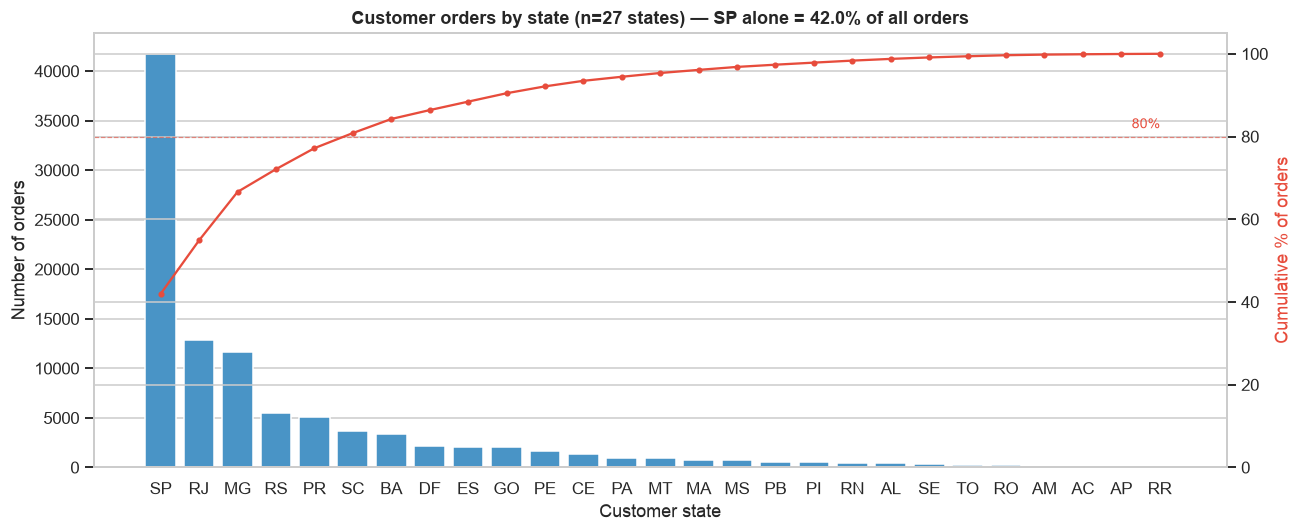

States needed to reach 80% of orders: 6 of 27


In [10]:
state_counts = fact_orders["customer_state"].value_counts()
state_cum_pct = 100 * state_counts.cumsum() / state_counts.sum()

fig, ax1 = plt.subplots(figsize=(12, 5))
sns.barplot(x=state_counts.index, y=state_counts.values, ax=ax1, color="#3498db")
ax1.set_xlabel("Customer state")
ax1.set_ylabel("Number of orders")
ax1.set_title(f"Customer orders by state (n={state_counts.shape[0]} states) — "
               f"SP alone = {100*state_counts.iloc[0]/state_counts.sum():.1f}% of all orders")

ax2 = ax1.twinx()
ax2.plot(range(len(state_cum_pct)), state_cum_pct.values, color="#e74c3c", marker="o", markersize=3)
ax2.set_ylabel("Cumulative % of orders", color="#e74c3c")
ax2.set_ylim(0, 105)
ax2.axhline(80, color="#e74c3c", linestyle="--", linewidth=0.8, alpha=0.6)
ax2.text(len(state_cum_pct) - 1, 82, "80%", color="#e74c3c", ha="right", fontsize=9)

plt.tight_layout()
plt.show()

print(f"States needed to reach 80% of orders: "
      f"{(state_cum_pct <= 80).sum() + 1} of {state_counts.shape[0]}")

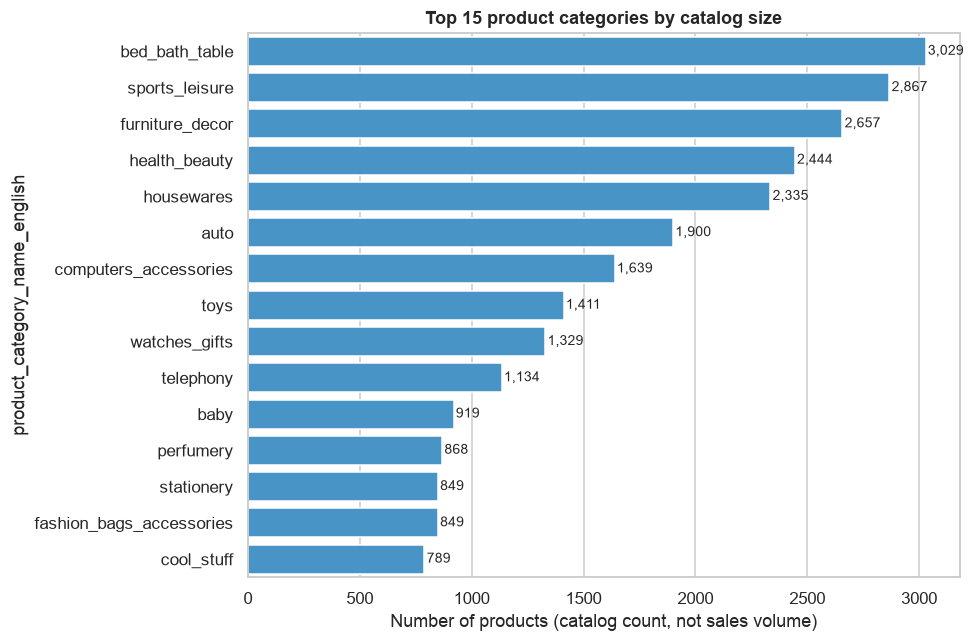

In [11]:
cat_counts = dim_product["product_category_name_english"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#e74c3c" if c == "unknown" else "#3498db" for c in cat_counts.index]
sns.barplot(x=cat_counts.values, y=cat_counts.index, ax=ax, hue=cat_counts.index, palette=colors, legend=False)
ax.set_xlabel("Number of products (catalog count, not sales volume)")
ax.set_title("Top 15 product categories by catalog size")
for i, v in enumerate(cat_counts.values):
    ax.text(v + 10, i, f"{v:,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

### Interpretation

- **Order funnel:** 97.02% of orders reach `delivered`. The remaining 2.98%
  splits across `shipped` (1.11%, in-flight at extract time), `canceled`
  (0.63%), `unavailable` (0.61% — seller-side stockouts), `invoiced`,
  `processing`, `created`, `approved` — all very small. This matches SQL
  Q3.1 exactly and confirms the dataset is overwhelmingly "complete" lifecycles.
- **Geography:** customer demand is **heavily concentrated in the Southeast** —
  SP alone is 42.0% of all orders, and just 4 states (SP, RJ, MG, RS) account
  for >70%. This concentration is explored fully (with maps) in Notebook 3
  (Geospatial Analysis) and is consistent with SQL Q2.6 (SP/RJ/MG = 62.5% of GMV).
- **Product categories:** 74 mapped categories plus the 610-product `unknown`
  bucket (4th largest by raw count, but — as Section 2 noted — immaterial to
  revenue). `bed_bath_table`, `sports_leisure`, `furniture_decor`, and
  `health_beauty` are the largest catalogs by SKU count; note this is **catalog
  breadth**, not revenue — SQL Q1.4 shows `health_beauty` and `watches_gifts`
  are actually the top *revenue* categories despite smaller catalogs, i.e.
  average selling price varies a lot by category (explored in Section 6).

## 4. Univariate Analysis — Numeric Distributions

We now characterize the shape of every key numeric variable: central tendency,
spread, **skewness** and **kurtosis** (both critical for choosing appropriate
transforms/statistical tests in later notebooks), then visualize each.

In [12]:
num_cols = ["order_total_value", "freight_value_total", "items_price_total",
            "review_score", "actual_delivery_days", "delivery_delay_days",
            "estimated_delivery_days", "n_items", "max_installments"]

desc = fact_orders[num_cols].describe().T
desc["skew"] = fact_orders[num_cols].skew()
desc["kurtosis"] = fact_orders[num_cols].kurtosis()
desc = desc[["count", "mean", "std", "min", "25%", "50%", "75%", "max", "skew", "kurtosis"]]
desc

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
order_total_value,"99,441.00",159.33,220.06,0.00,61.05,104.56,176.00,"13,664.08",9.22,239.79
freight_value_total,"99,441.00",22.65,21.66,0.00,13.72,17.09,23.92,"1,794.96",11.96,560.41
items_price_total,"99,441.00",136.68,210.17,0.00,45.00,85.00,149.90,"13,440.00",9.73,266.58
review_score,"98,673.00",4.09,1.35,1.00,4.00,5.00,5.00,5.00,-1.36,0.51
actual_delivery_days,"96,476.00",12.56,9.55,0.53,6.77,10.22,15.72,209.63,3.83,39.31
delivery_delay_days,"96,476.00",-11.18,10.19,-146.02,-16.24,-11.95,-6.39,188.98,2.01,28.02
estimated_delivery_days,"99,441.00",23.77,8.83,1.65,18.33,23.24,28.42,155.14,0.99,5.25
n_items,"99,441.00",1.13,0.55,0.00,1.00,1.00,1.00,21.00,7.15,108.48
max_installments,"99,440.00",2.93,2.72,0.00,1.00,2.00,4.00,24.00,1.60,2.35


**Reading the skew/kurtosis columns:**

- **`order_total_value`, `freight_value_total`, `items_price_total`** are
  *extremely* right-skewed (skew 9.2–12.0, kurtosis 240–560) — a tiny number
  of very large orders (max $13,664 vs. median $104.56) stretch the tail far
  beyond a normal distribution. This is the textbook shape of monetary data in
  retail — **log transforms will be essential** for any modeling work
  (Notebook 6) and for visualizing the bulk of the distribution (below).
- **`review_score`** is left-skewed (skew = -1.36): most orders get 4–5 stars,
  with a smaller but real spike at 1 star — a **J-shaped / bimodal "love it or
  hate it"** pattern typical of online review systems.
- **`actual_delivery_days`** (skew 3.83) and **`delivery_delay_days`** (skew
  2.01) are also right-skewed — most deliveries are reasonably fast and
  comfortably ahead of estimate, but a long tail of very slow deliveries
  (max 209.6 days!) pulls the mean well above the median.
- **`n_items`** (skew 7.15): the overwhelming majority of orders contain
  exactly 1 item (median = 1, 75th pctile = 1), with rare large multi-item
  orders (max 21).

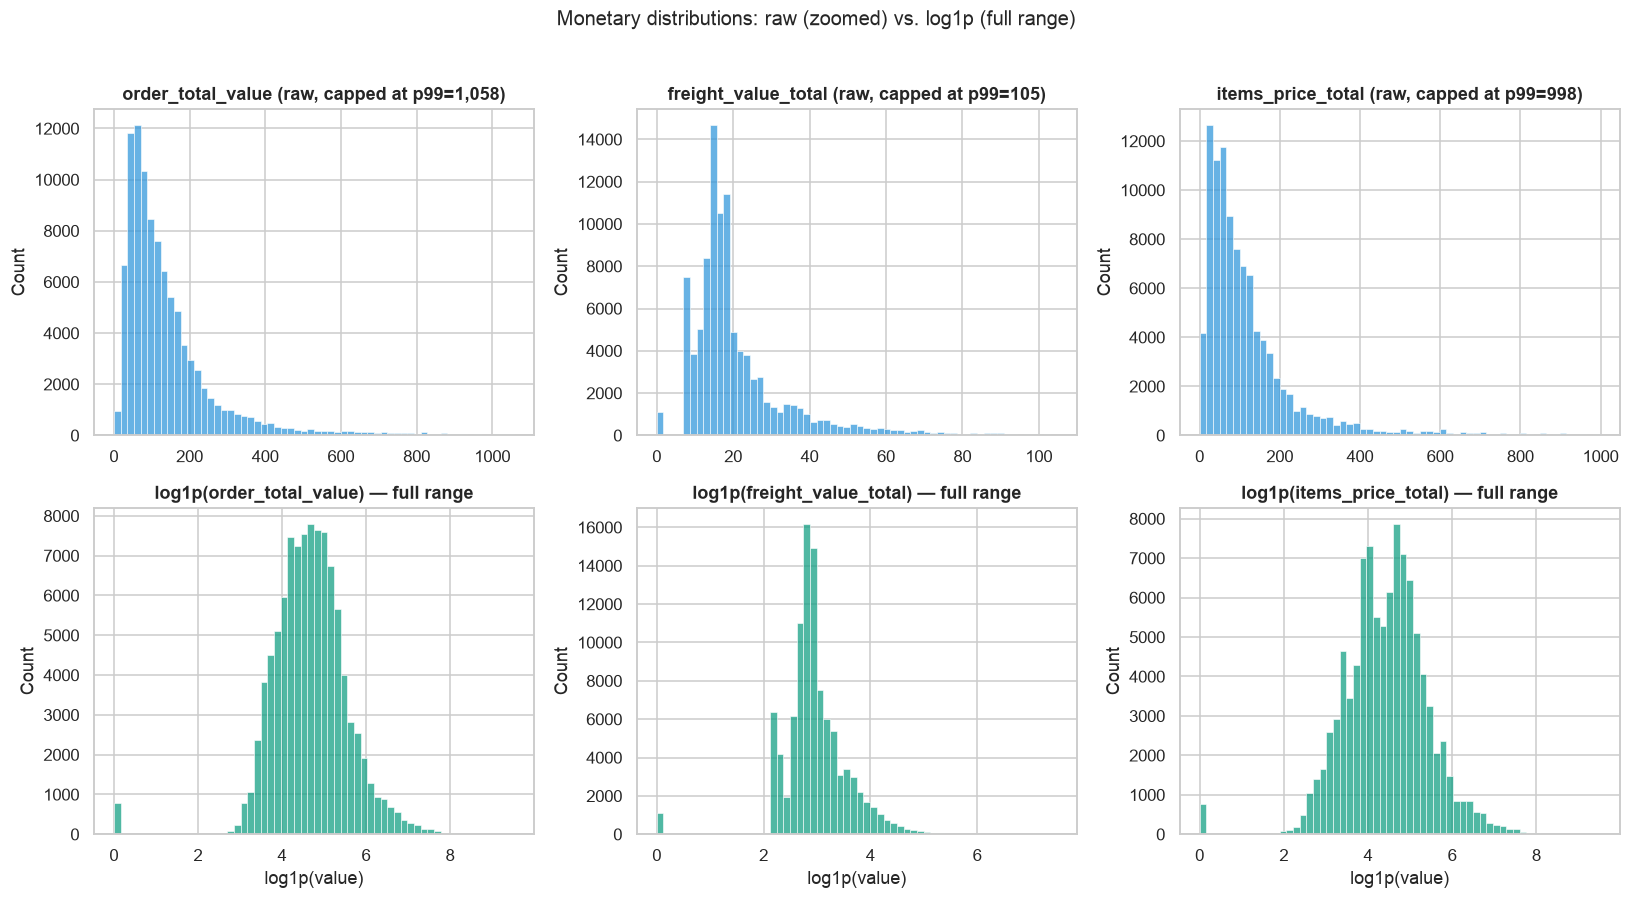

In [13]:
monetary_cols = ["order_total_value", "freight_value_total", "items_price_total"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(monetary_cols):
    # Raw scale (zoomed to 99th percentile so the bulk of the distribution is visible)
    cap = fact_orders[col].quantile(0.99)
    sns.histplot(fact_orders[fact_orders[col] <= cap][col], bins=60, ax=axes[0, i], color="#3498db")
    axes[0, i].set_title(f"{col} (raw, capped at p99={cap:,.0f})")
    axes[0, i].set_xlabel("")

    # Log1p scale (full range, all rows incl. zeros from no-item orders)
    sns.histplot(np.log1p(fact_orders[col]), bins=60, ax=axes[1, i], color="#16a085")
    axes[1, i].set_title(f"log1p({col}) — full range")
    axes[1, i].set_xlabel("log1p(value)")

plt.suptitle("Monetary distributions: raw (zoomed) vs. log1p (full range)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

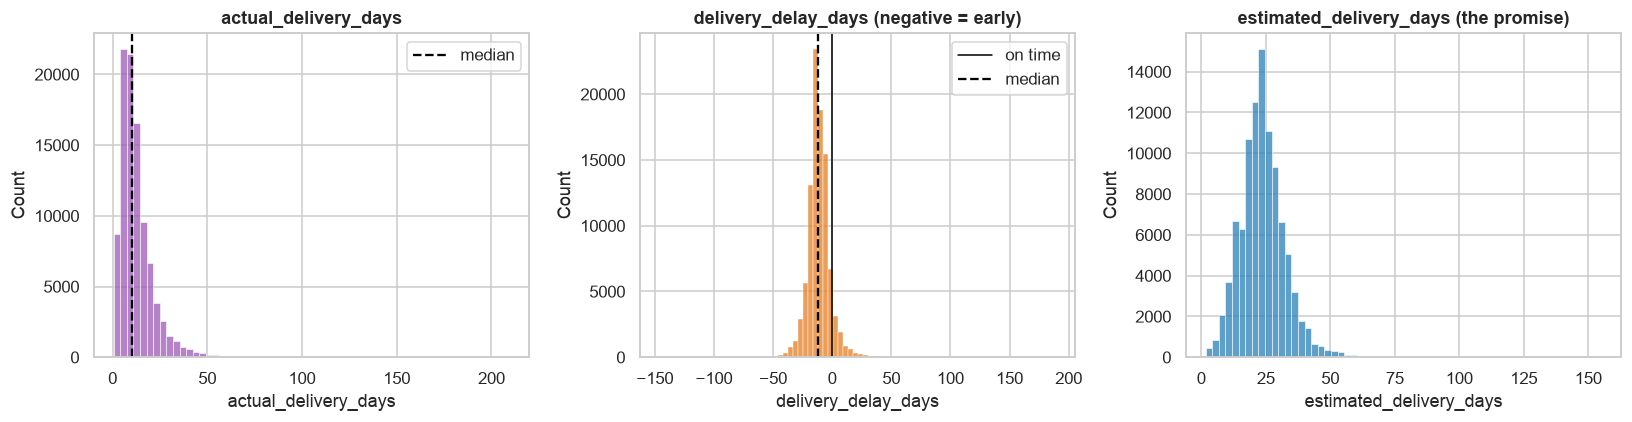

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(fact_orders["actual_delivery_days"].dropna(), bins=60, ax=axes[0], color="#9b59b6")
axes[0].set_title("actual_delivery_days")
axes[0].axvline(fact_orders["actual_delivery_days"].median(), color="black", linestyle="--", label="median")
axes[0].legend()

sns.histplot(fact_orders["delivery_delay_days"].dropna(), bins=80, ax=axes[1], color="#e67e22")
axes[1].set_title("delivery_delay_days (negative = early)")
axes[1].axvline(0, color="black", linestyle="-", linewidth=1, label="on time")
axes[1].axvline(fact_orders["delivery_delay_days"].median(), color="black", linestyle="--", label="median")
axes[1].legend()

sns.histplot(fact_orders["estimated_delivery_days"], bins=60, ax=axes[2], color="#2980b9")
axes[2].set_title("estimated_delivery_days (the promise)")

plt.tight_layout()
plt.show()

**Delivery timing distributions:**

- `actual_delivery_days` is right-skewed around a median of 10.2 days, with a
  long tail (mean 12.6, max 209.6 — almost 7 months for a handful of orders).
- `delivery_delay_days` is centered well **below zero** (median -11.9, mean
  -11.2) — i.e. **the median order arrives almost 12 days before its estimated
  delivery date**. This single statistic foreshadows SQL Q3.6's finding that
  73.9% of delivered orders arrive 7+ days ahead of estimate — Olist's promise
  dates appear to be deliberately padded. The right tail (max +189 days late)
  represents genuine severe-delay outliers.
- `estimated_delivery_days` (the promise itself) is centered around 23 days
  with its own right tail (max 155 days) — some product categories evidently
  carry very long lead-time promises (large furniture, custom orders).

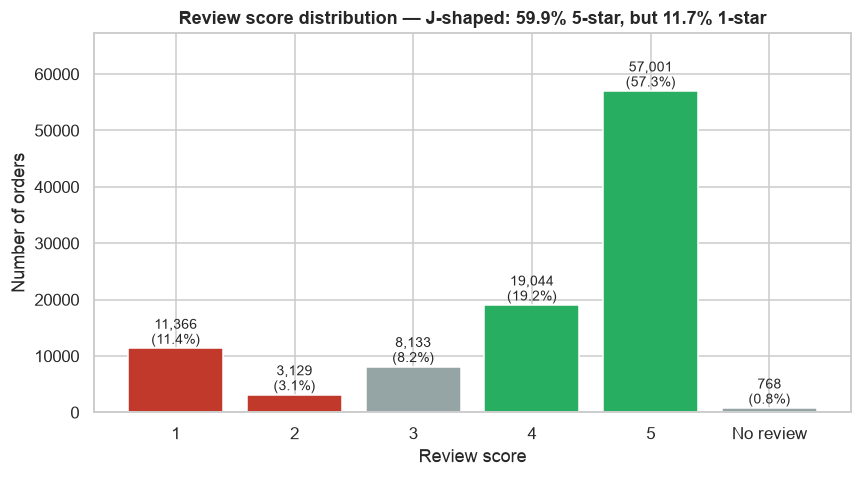

In [15]:
review_counts = fact_orders["review_score"].value_counts(dropna=False).sort_index()
review_pct = 100 * review_counts / review_counts.sum()

fig, ax = plt.subplots(figsize=(8, 4.5))
labels = [str(int(x)) if pd.notna(x) else "No review" for x in review_counts.index]
colors = ["#27ae60" if l in ("4", "5") else ("#c0392b" if l in ("1", "2") else "#95a5a6") for l in labels]
bars = ax.bar(labels, review_counts.values, color=colors)
ax.set_xlabel("Review score")
ax.set_ylabel("Number of orders")
ax.set_title("Review score distribution — J-shaped: 59.9% 5-star, but 11.7% 1-star")
for bar, v, p in zip(bars, review_counts.values, review_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 800, f"{v:,}\n({p:.1f}%)",
            ha="center", fontsize=9)
ax.set_ylim(0, review_counts.max() * 1.18)
plt.tight_layout()
plt.show()

**Review score — the "love it or hate it" pattern:** 59.9% of reviewed orders
get 5 stars and another 19.8% get 4 stars (79.7% are "satisfied"), but 11.7% are
1-star — more than double the 3.3% who give 2 stars, and more than the 8.4% who
give 3 stars combined. This **non-monotonic** shape (5 ★ ≫ 4 ★ > 3 ★ < 1 ★ > 2 ★)
is the classic signature of reviews driven by *extreme* experiences — strongly
suggesting that **a small set of operational failures (most plausibly late
delivery — quantified in Section 6 and formally tested in Notebook 4) is
generating a disproportionate share of the 1-star reviews**, rather than 1-star
reviews being "mild dissatisfaction" spread evenly across the scale.

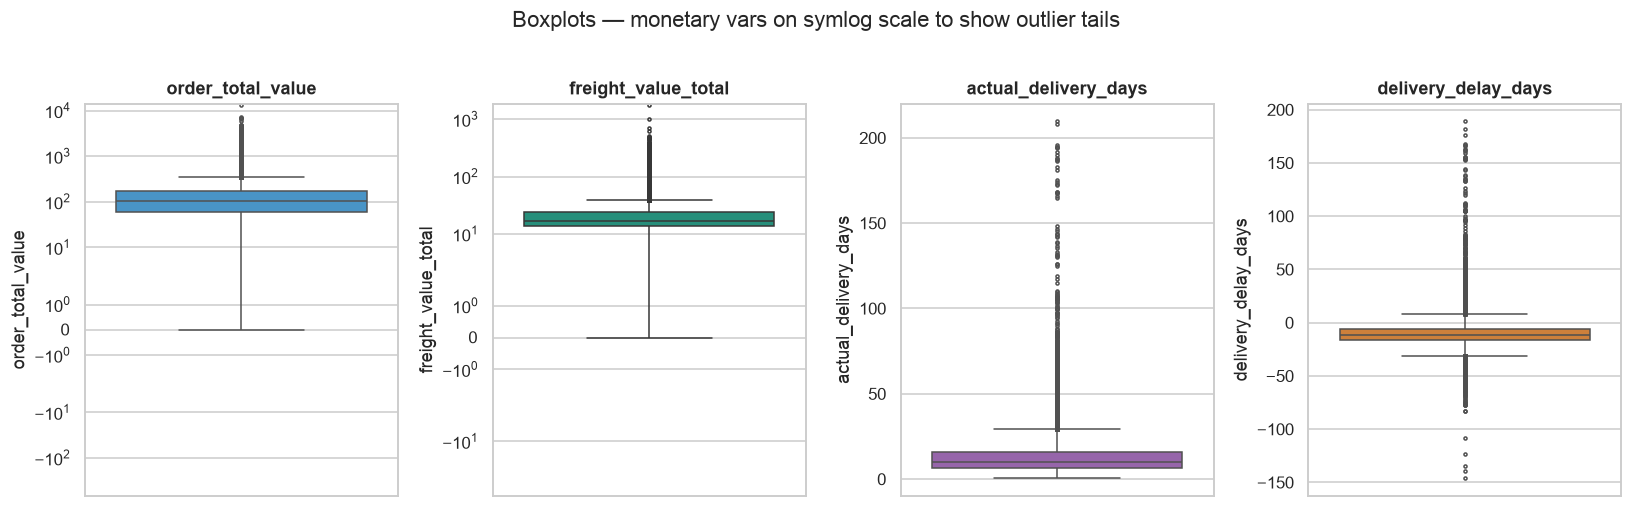

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4.5))

for ax, col, color in zip(axes,
                           ["order_total_value", "freight_value_total", "actual_delivery_days", "delivery_delay_days"],
                           ["#3498db", "#16a085", "#9b59b6", "#e67e22"]):
    data = np.log1p(fact_orders[col]) if "delivery" not in col else fact_orders[col]
    sns.boxplot(y=fact_orders[col] if "delivery" not in col else fact_orders[col],
                ax=ax, color=color, fliersize=2)
    if "delivery" not in col:
        ax.set_yscale("symlog")
    ax.set_title(col)

plt.suptitle("Boxplots — monetary vars on symlog scale to show outlier tails", y=1.02)
plt.tight_layout()
plt.show()

## 5. Outlier Detection

We apply the standard **Tukey IQR rule** (outlier if `x < Q1 - 1.5·IQR` or
`x > Q3 + 1.5·IQR`) to the key monetary and timing variables, then **investigate
the most extreme cases individually** — the senior-analyst step that separates
"flag and ignore" from "flag and understand."

In [17]:
def iqr_outlier_summary(series, label):
    s = series.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((s < lo) | (s > hi)).sum()
    n_out_hi = (s > hi).sum()
    return {
        "variable": label, "Q1": q1, "Q3": q3, "IQR": iqr,
        "lower_bound": lo, "upper_bound": hi,
        "n_outliers": n_out, "pct_outliers": 100 * n_out / len(s),
        "n_outliers_high": n_out_hi, "max": s.max(),
    }

outlier_summary = pd.DataFrame([
    iqr_outlier_summary(fact_orders["order_total_value"], "order_total_value"),
    iqr_outlier_summary(fact_items["price"], "price (item-level)"),
    iqr_outlier_summary(fact_items["freight_value"], "freight_value (item-level)"),
    iqr_outlier_summary(fact_orders["actual_delivery_days"], "actual_delivery_days"),
    iqr_outlier_summary(fact_orders["delivery_delay_days"], "delivery_delay_days"),
]).set_index("variable")
outlier_summary

,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers,pct_outliers,n_outliers_high,max
variable,,,,,,,,,
order_total_value,61.05,176.00,114.95,-111.38,348.43,7812,7.86,7812,"13,664.08"
price (item-level),39.90,134.90,95.00,-102.60,277.40,8427,7.48,8427,"6,735.00"
freight_value (item-level),13.08,21.15,8.07,0.98,33.25,12134,10.77,11613,409.68
actual_delivery_days,6.77,15.72,8.95,-6.66,29.15,4899,5.08,4899,209.63
delivery_delay_days,-16.24,-6.39,9.85,-31.03,8.39,4875,5.05,2830,188.98


**Reading this table:** between 5–11% of values fall outside the Tukey fences
for every monetary/timing variable — at first glance "10% outliers" sounds
alarming, but with skew this extreme (Section 4), **the IQR rule itself is the
wrong lens**: a distribution this lognormal-shaped will *always* flag a large
fraction of its right tail as "outliers" even though those are perfectly valid
high-value orders / slow-but-real deliveries, not data errors. The right
question isn't "how many outliers" but **"are the extreme values legitimate,
and do they need separate handling in downstream analysis?"** — answered below
for the single most extreme order.

In [18]:
top10 = fact_orders.nlargest(10, "order_total_value")[
    ["order_id", "order_status", "n_items", "items_price_total",
     "freight_value_total", "order_total_value", "review_score", "customer_state"]
]
top10

,order_id,order_status,n_items,items_price_total,freight_value_total,order_total_value,review_score,customer_state
85415,03caa2c082116e1d31e67e9ae3700499,delivered,8,"13,440.00",224.08,"13,664.08",1.00,RJ
59084,736e1922ae60d0d6a89247b851902527,delivered,4,"7,160.00",114.88,"7,274.88",1.00,ES
89330,0812eb902a67711a1cb742b3cdaa65ae,delivered,1,"6,735.00",194.31,"6,929.31",5.00,MS
84578,fefacc66af859508bf1a7934eab1e97f,delivered,1,"6,729.00",193.21,"6,922.21",NaN,ES
56548,f5136e38d1a14a4dbd87dff67da82701,delivered,1,"6,499.00",227.66,"6,726.66",5.00,SP
2278,2cc9089445046817a7539d90805e6e5a,delivered,6,"5,934.60",146.94,"6,081.54",1.00,MG
36972,a96610ab360d42a2e5335a3998b4718a,delivered,1,"4,799.00",151.34,"4,950.34",5.00,RJ
70964,b4c4b76c642808cbe472a32b86cddc95,canceled,2,"4,599.90",209.54,"4,809.44",1.00,GO
95926,199af31afc78c699f0dbf71fb178d4d4,delivered,1,"4,690.00",74.34,"4,764.34",4.00,SP
31134,8dbc85d1447242f3b127dda390d56e19,delivered,1,"4,590.00",91.78,"4,681.78",5.00,PB


In [19]:
# Deep dive on the single highest-value order
top_order_id = top10.iloc[0]["order_id"]
top_items = (fact_items[fact_items["order_id"] == top_order_id]
              .merge(dim_product[["product_id", "product_category_name_english"]],
                     on="product_id", how="left"))
print(f"Order {top_order_id} — order_total_value = "
      f"${fact_orders.loc[fact_orders['order_id']==top_order_id, 'order_total_value'].iloc[0]:,.2f}, "
      f"review_score = {fact_orders.loc[fact_orders['order_id']==top_order_id, 'review_score'].iloc[0]:.0f}")
top_items[["order_item_id", "product_id", "product_category_name_english", "price", "freight_value"]]

Order 03caa2c082116e1d31e67e9ae3700499 — order_total_value = $13,664.08, review_score = 1


,order_item_id,product_id,product_category_name_english,price,freight_value
0,1,5769ef0a239114ac3a854af00df129e4,fixed_telephony,"1,680.00",28.01
1,2,5769ef0a239114ac3a854af00df129e4,fixed_telephony,"1,680.00",28.01
2,3,5769ef0a239114ac3a854af00df129e4,fixed_telephony,"1,680.00",28.01
3,4,5769ef0a239114ac3a854af00df129e4,fixed_telephony,"1,680.00",28.01
4,5,5769ef0a239114ac3a854af00df129e4,fixed_telephony,"1,680.00",28.01
5,6,5769ef0a239114ac3a854af00df129e4,fixed_telephony,"1,680.00",28.01
6,7,5769ef0a239114ac3a854af00df129e4,fixed_telephony,"1,680.00",28.01
7,8,5769ef0a239114ac3a854af00df129e4,fixed_telephony,"1,680.00",28.01


### Interpretation — the #1 order is a legitimate (if unusual) bulk purchase, and it's a 1-star review

The single highest-value order (\$13,664.08, RJ) is **8 identical units of one
`fixed_telephony` product at \$1,680 each** — almost certainly a small-business
bulk purchase (e.g., a reseller or office equipping a multi-line phone system),
not a data-entry error (the per-unit price and per-unit freight are both
internally consistent across all 8 line items).

The fact that this order also carries a **1-star review** is a striking
anecdote — but exactly that, an anecdote (n=1). It's *consistent* with the
broader delay→dissatisfaction relationship explored in Section 6/Notebook 4
(perhaps this large order was the one most likely to encounter a fulfillment
problem), but we deliberately **do not generalize from a single data point**.
What this deep-dive *does* establish is that **the extreme right tail of
`order_total_value` represents real B2B-style bulk orders that should be
*kept* in revenue analysis** (they're real GMV) but watched separately in any
"per-order" average that could be skewed by a handful of these (e.g., AOV by
state — Q2.6 already uses `SUM`/`COUNT` ratios rather than `AVG` of an
already-aggregated column, which is the correct defensive choice).

In [20]:
zero_item = fact_orders[fact_orders["n_items"] == 0]
print(f"Orders with n_items == 0: {len(zero_item)} ({100*len(zero_item)/len(fact_orders):.2f}% of all orders)")
print(zero_item["order_status"].value_counts().to_string())
print(f"\nAll have order_total_value == 0: {(zero_item['order_total_value'] == 0).all()}")

Orders with n_items == 0: 775 (0.78% of all orders)
order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1

All have order_total_value == 0: True


The 775 "zero-item" orders (0.78%) — almost entirely `unavailable` (603, 77.8%)
and `canceled` (164, 21.2%) — are orders where **every line item was removed**
before the extract (e.g., a seller marking their only SKU out of stock after
the order was placed). All correctly carry `order_total_value = 0` via the
`COALESCE` in the `fact_orders` build, and all SQL revenue queries exclude
`canceled`/`unavailable` orders entirely (per the header note in every
`sql/analytics` file), so these contribute **zero distortion** to any GMV
metric. This is a "verify the zero, then move on" case — exactly the kind of
five-minute check that prevents a much longer debugging session later.

## 6. Bivariate Analysis

We now examine pairwise relationships that matter most for the business
questions ahead: price vs. freight (logistics cost structure), delivery delay
vs. review score (the Customer-Obsession thread), category vs. price/freight
(merchandising), and payment installments vs. order value (checkout behavior).

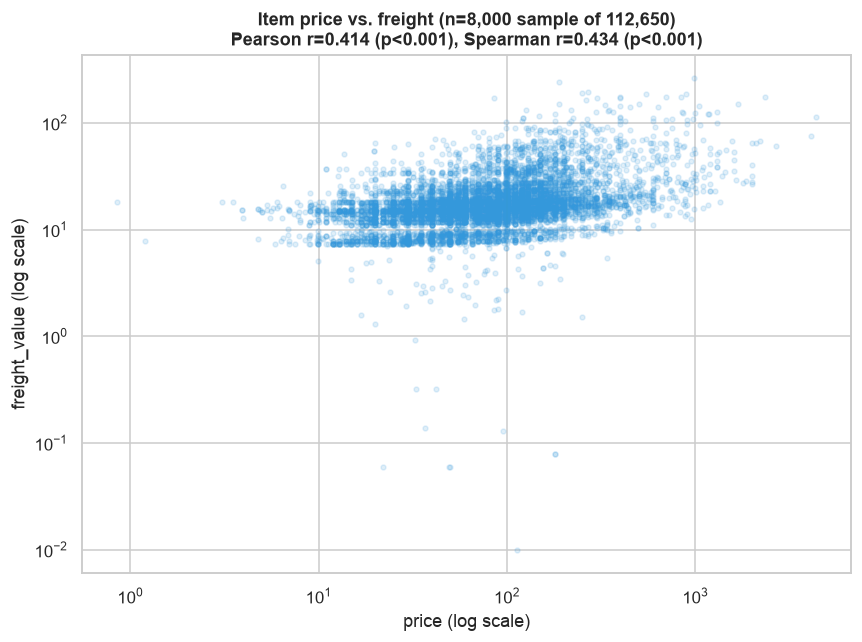

In [21]:
sample = fact_items[["price", "freight_value"]].sample(8000, random_state=42)
pearson_r, pearson_p = stats.pearsonr(fact_items["price"], fact_items["freight_value"])
spearman_r, spearman_p = stats.spearmanr(fact_items["price"], fact_items["freight_value"])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(sample["price"], sample["freight_value"], alpha=0.15, s=10, color="#3498db")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("price (log scale)")
ax.set_ylabel("freight_value (log scale)")
ax.set_title(f"Item price vs. freight (n=8,000 sample of 112,650)\n"
              f"Pearson r={pearson_r:.3f} (p<0.001), Spearman r={spearman_r:.3f} (p<0.001)")
plt.tight_layout()
plt.show()

**Price vs. freight: moderate positive correlation (r ≈ 0.41–0.43), not strong.**
More expensive items tend to cost more to ship, but the relationship is loose —
visually, the scatter is a wide cloud rather than a tight line, and the log-log
view shows freight cost compresses much less than price does (freight ranges
roughly \$0–$410 vs. price \$0.85–$6,735, a much narrower dynamic range). This
makes sense physically: **freight is driven primarily by weight/dimensions and
distance, not declared value** — a heavy, cheap item (e.g., furniture) can have
high freight despite low price, while a small, expensive item (e.g., electronics)
can have low freight despite high price. This has a direct implication for
Notebook 6 (predictive modeling): `price` alone is a weak proxy for shipping
cost/time — `product_weight_g`/dimensions (available in `dim_product`) would be
better features if shipping-time prediction were in scope.

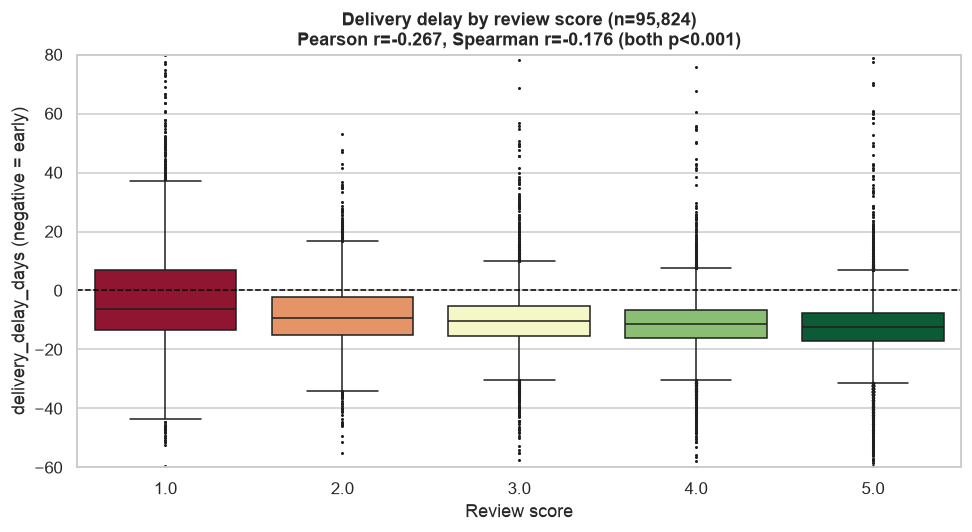

In [22]:
delivered = fact_orders[fact_orders["is_delivered"] & ~fact_orders["dq_delivered_missing_date"]
                          & fact_orders["review_score"].notna()].copy()

pearson_r, pearson_p = stats.pearsonr(delivered["delivery_delay_days"], delivered["review_score"])
spearman_r, spearman_p = stats.spearmanr(delivered["delivery_delay_days"], delivered["review_score"])

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=delivered, x="review_score", y="delivery_delay_days", ax=ax,
            hue="review_score", palette="RdYlGn", legend=False, fliersize=1)
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_ylim(-60, 80)
ax.set_xlabel("Review score")
ax.set_ylabel("delivery_delay_days (negative = early)")
ax.set_title(f"Delivery delay by review score (n={len(delivered):,})\n"
              f"Pearson r={pearson_r:.3f}, Spearman r={spearman_r:.3f} (both p<0.001)")
plt.tight_layout()
plt.show()

**Delivery delay vs. review score: a real but moderate negative correlation**
(Pearson r = -0.267, Spearman r = -0.176, both highly significant at this
sample size). The boxplot shows the *median* delay is similar (and comfortably
"early") across scores 2–5, but **1-star reviews have a visibly higher median
delay and a much fatter positive (late) tail** — consistent with SQL Q3.5's
descriptive cut (avg review score falls from 4.30 for "2+ days early" orders to
1.73 for "8+ days late" orders, and `pct_1star` rises from 6.6% to 68.8%).

The fact that Pearson and Spearman disagree noticeably (r=-0.267 vs. -0.176)
signals **non-linearity** — the relationship looks like a "cliff": review score
stays high across a wide range of "early/on-time" delays, then drops sharply
once an order crosses into "late." This motivates a **formal non-parametric
test and a delay-bucket ANOVA/Kruskal-Wallis** rather than relying on Pearson
correlation alone — done properly in Notebook 4 (Hypothesis Testing).

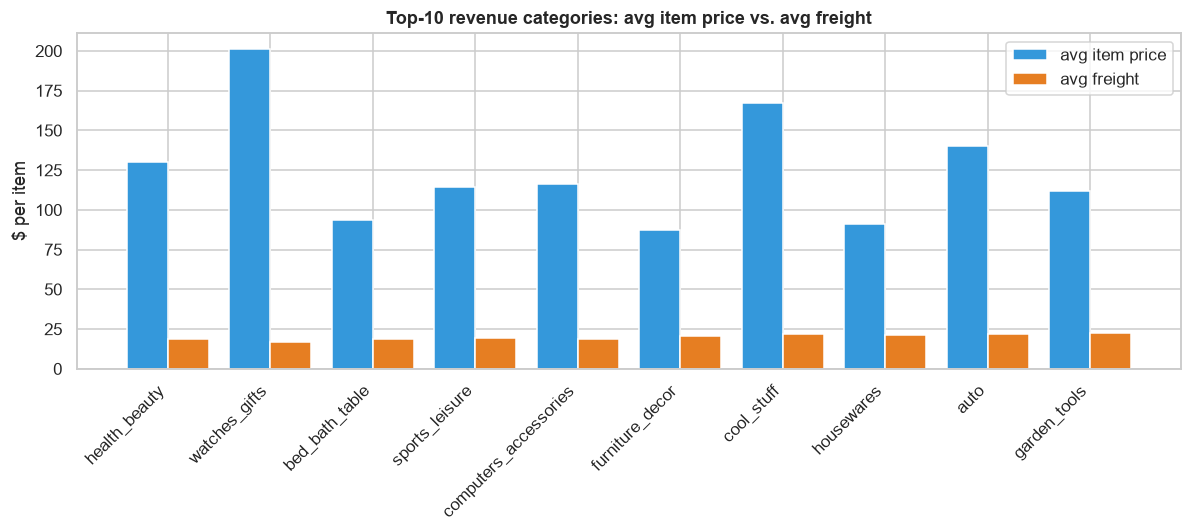

,revenue,avg_price,n_items,avg_freight
product_category_name_english,,,,
health_beauty,"1,258,681.34",130.16,9670,18.88
watches_gifts,"1,205,005.68",201.14,5991,16.78
bed_bath_table,"1,036,988.68",93.30,11115,18.42
sports_leisure,"988,048.97",114.34,8641,19.51
computers_accessories,"911,954.32",116.51,7827,18.82
furniture_decor,"729,762.49",87.56,8334,20.73
cool_stuff,"635,290.85",167.36,3796,22.14
housewares,"632,248.66",90.79,6964,20.99
auto,"592,720.11",139.96,4235,21.88


In [23]:
items_cat = fact_items.merge(dim_product[["product_id", "product_category_name_english"]],
                              on="product_id", how="left")
top10_cat = (items_cat.groupby("product_category_name_english")["price"]
              .agg(revenue="sum", avg_price="mean", n_items="count")
              .sort_values("revenue", ascending=False).head(10))

# bring in avg freight for the same categories
top10_freight = (items_cat[items_cat["product_category_name_english"].isin(top10_cat.index)]
                  .groupby("product_category_name_english")["freight_value"].mean())
top10_cat["avg_freight"] = top10_freight

fig, ax1 = plt.subplots(figsize=(11, 5))
x = np.arange(len(top10_cat))
width = 0.4
ax1.bar(x - width/2, top10_cat["avg_price"], width, label="avg item price", color="#3498db")
ax1.bar(x + width/2, top10_cat["avg_freight"], width, label="avg freight", color="#e67e22")
ax1.set_xticks(x)
ax1.set_xticklabels(top10_cat.index, rotation=45, ha="right")
ax1.set_ylabel("$ per item")
ax1.set_title("Top-10 revenue categories: avg item price vs. avg freight")
ax1.legend()
plt.tight_layout()
plt.show()

top10_cat

**Category economics:** `watches_gifts` and `cool_stuff` stand out with high
average prices (\$201 and \$167) relative to their freight (\$16–17) — a
**favorable freight-to-price ratio** (cheap to ship relative to value). At the
other end, `bed_bath_table`, `furniture_decor`, and `housewares` have low
average prices (\$87–93) but **freight costs that are a much larger fraction of
item value** (often >20%) — these categories are "bulky" (large/heavy items at
modest price points), which directly explains why SQL Q4.4 found **same-state
seller↔customer pairs have ~43% lower freight than cross-state pairs** —
distance matters disproportionately for exactly this kind of bulky, low-value
item.

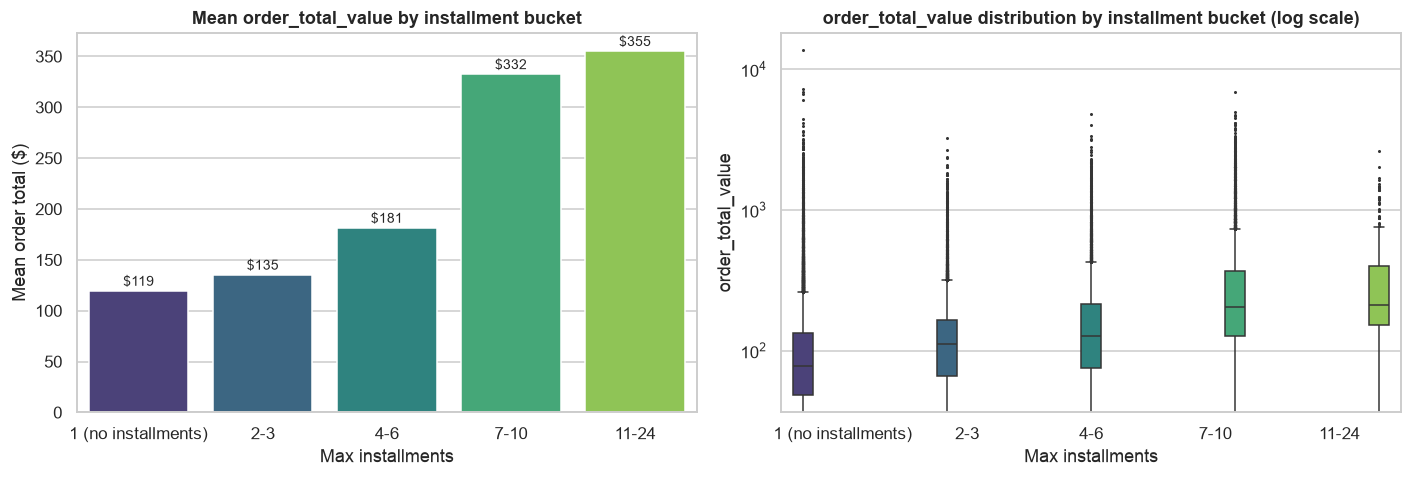

,n,mean,median
installment_bucket,,,
1 (no installments),48270,119.45,78.57
2-3,22792,135.26,111.03
4-6,16205,181.41,127.92
7-10,11832,332.48,205.41
11-24,341,355.14,212.03


In [24]:
pay = fact_orders[fact_orders["max_installments"].notna()].copy()
pay["installment_bucket"] = pd.cut(pay["max_installments"], bins=[0, 1, 3, 6, 10, 24],
                                    labels=["1 (no installments)", "2-3", "4-6", "7-10", "11-24"],
                                    include_lowest=True)
inst_summary = pay.groupby("installment_bucket", observed=True)["order_total_value"].agg(
    n="count", mean="mean", median="median")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(x=inst_summary.index.astype(str), y=inst_summary["mean"], ax=axes[0],
            hue=inst_summary.index.astype(str), palette="viridis", legend=False)
axes[0].set_title("Mean order_total_value by installment bucket")
axes[0].set_ylabel("Mean order total ($)")
axes[0].set_xlabel("Max installments")
for i, v in enumerate(inst_summary["mean"]):
    axes[0].text(i, v + 5, f"${v:,.0f}", ha="center", fontsize=9)

sns.boxplot(data=pay, x="installment_bucket", y="order_total_value", ax=axes[1],
            hue="installment_bucket", palette="viridis", legend=False, fliersize=1)
axes[1].set_yscale("log")
axes[1].set_title("order_total_value distribution by installment bucket (log scale)")
axes[1].set_xlabel("Max installments")

plt.tight_layout()
plt.show()

inst_summary

**Installments as a financing signal:** mean `order_total_value` rises
monotonically and dramatically with the number of installments chosen — from
\$119 for single-payment orders to **\$355 for 11–24 installment orders (3x
higher)**. This is exactly what we'd expect if installment plans are used to
*finance larger purchases* — a behavioral pattern with direct implications for
Amazon-style "Pay over time" / "Monthly Payments" product features: **higher
basket value is the single strongest behavioral predictor of installment use**
in this dataset, ahead of category or geography.

## 7. Multivariate Analysis

Bivariate correlations can be misleading in isolation — a variable's
relationship with the outcome can change once other variables are held
constant, or two variables may *both* drive a third. We close with a
correlation matrix across all key numeric drivers, a multi-dimensional
pairplot split by satisfaction level, and a two-way heatmap that tests whether
the delay→review relationship (Section 6) holds **uniformly across order
values** or is itself an interaction effect.

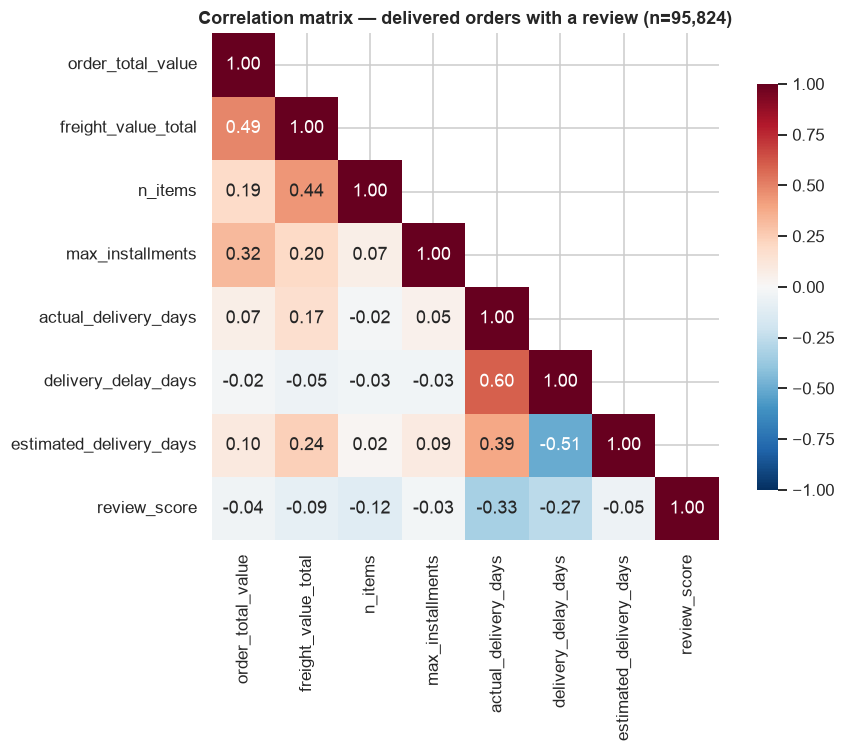

In [25]:
corr_cols = ["order_total_value", "freight_value_total", "n_items", "max_installments",
             "actual_delivery_days", "delivery_delay_days", "estimated_delivery_days", "review_score"]
corr = delivered[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title(f"Correlation matrix — delivered orders with a review (n={len(delivered):,})")
plt.tight_layout()
plt.show()

**Three findings stand out from the correlation matrix:**

1. **`delivery_delay_days` vs. `estimated_delivery_days`: r = -0.51** — the
   *strongest* relationship in the matrix after the (mechanical)
   `actual_delivery_days`↔`delivery_delay_days` pair. Orders with a **longer
   promised delivery window end up arriving relatively *earlier* vs. that
   promise** — i.e., long estimates are padded *more generously* than short
   ones. This is a meaningful operational finding: Olist's promise-date model
   doesn't add a fixed buffer, it appears to add a buffer that *grows* with the
   base estimate, perhaps because long-lead-time categories (furniture, etc.)
   carry extra contingency built in by sellers.

2. **`actual_delivery_days` vs. `delivery_delay_days`: r = 0.60** — slower
   absolute delivery is associated with being *later relative to estimate too*
   (not just "everything takes longer but estimates scale with it"). Combined
   with finding #1, this suggests two distinct sub-populations: most orders
   have moderate delivery times *and* comfortable padding, while a slower-tail
   of orders both takes longer *and* erodes/exceeds its padding — exactly the
   kind of order Notebook 6's late-delivery classifier should be able to
   separate out.

3. **`review_score`'s strongest negative correlations are with
   `actual_delivery_days` (-0.33) and `delivery_delay_days` (-0.27)** —
   *larger in magnitude* than its correlation with `order_total_value` (-0.04)
   or `freight_value_total` (-0.09). **Delivery experience dominates price as a
   driver of satisfaction** in this dataset — directly actionable: an Amazon
   Ops/CX team should prioritize delivery-time variance reduction over, say,
   shipping-cost reduction, if the goal is review-score improvement.

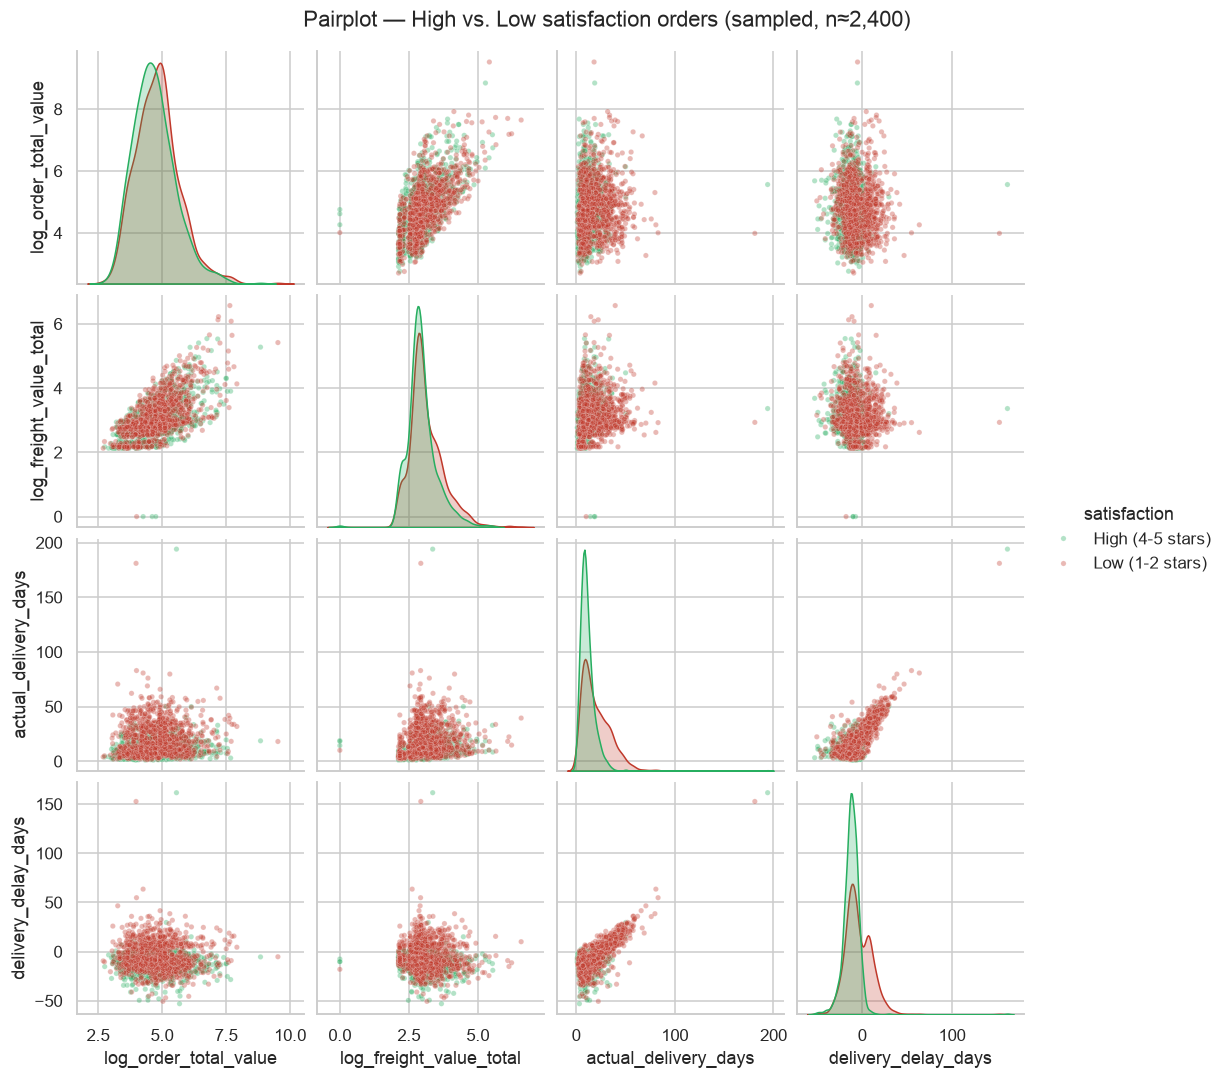

In [26]:
pp = delivered[delivered["review_score"].isin([1, 2, 4, 5])].copy()
pp["satisfaction"] = np.where(pp["review_score"] >= 4, "High (4-5 stars)", "Low (1-2 stars)")
pp_sample = pp.groupby("satisfaction", group_keys=False).apply(
    lambda d: d.sample(min(1200, len(d)), random_state=42), include_groups=False
)
pp_sample["satisfaction"] = pp.loc[pp_sample.index, "satisfaction"]

pp_sample["log_order_total_value"] = np.log1p(pp_sample["order_total_value"])
pp_sample["log_freight_value_total"] = np.log1p(pp_sample["freight_value_total"])

g = sns.pairplot(
    pp_sample,
    vars=["log_order_total_value", "log_freight_value_total", "actual_delivery_days", "delivery_delay_days"],
    hue="satisfaction", palette={"High (4-5 stars)": "#27ae60", "Low (1-2 stars)": "#c0392b"},
    plot_kws=dict(alpha=0.35, s=12), diag_kind="kde", height=2.4,
)
g.fig.suptitle("Pairplot — High vs. Low satisfaction orders (sampled, n≈2,400)", y=1.02)
plt.show()

**Pairplot interpretation:** the clearest separation between high- and
low-satisfaction orders is visible on the **`delivery_delay_days`** axis — the
red ("Low", 1-2 stars) distribution is shifted noticeably toward positive (late)
values and has a much heavier right tail, while the green ("High", 4-5 stars)
distribution is sharply concentrated in negative (early) territory. The
**`log_order_total_value`** and
**`log_freight_value_total`** marginal distributions, by contrast, look
*nearly identical* between the two groups — visually confirming the correlation
matrix's finding that price/freight barely move the needle on satisfaction
compared to delivery timing. The `actual_delivery_days` panels show a similar
(if weaker) rightward shift for low-satisfaction orders.

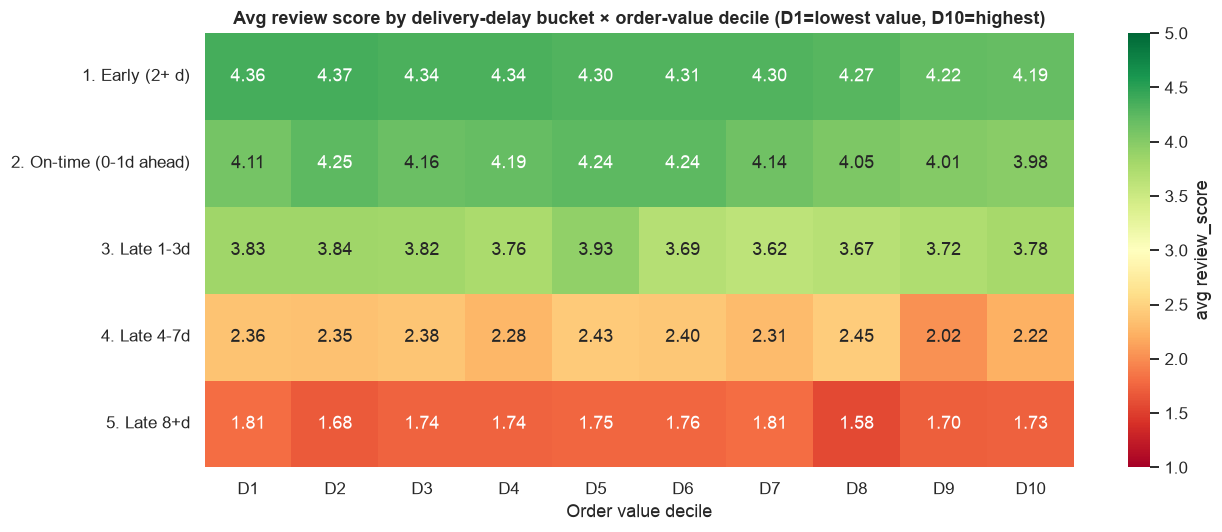


n orders per delay bucket:
delay_bucket
1. Early (2+ d)            85173
2. On-time (0-1d ahead)     2990
3. Late 1-3d                2636
4. Late 4-7d                1773
5. Late 8+d                 3252


In [27]:
delivered["delay_bucket"] = pd.cut(
    delivered["delivery_delay_days"],
    bins=[-np.inf, -2, 0, 3, 7, np.inf],
    labels=["1. Early (2+ d)", "2. On-time (0-1d ahead)", "3. Late 1-3d", "4. Late 4-7d", "5. Late 8+d"]
)
delivered["value_decile"] = pd.qcut(delivered["order_total_value"], 10,
                                     labels=[f"D{i}" for i in range(1, 11)], duplicates="drop")

pivot = delivered.pivot_table(index="delay_bucket", columns="value_decile",
                               values="review_score", aggfunc="mean")

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", vmin=1, vmax=5, ax=ax,
            cbar_kws={"label": "avg review_score"})
ax.set_title("Avg review score by delivery-delay bucket × order-value decile (D1=lowest value, D10=highest)")
ax.set_xlabel("Order value decile")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

n_per_bucket = delivered["delay_bucket"].value_counts().sort_index()
print("\nn orders per delay bucket:")
print(n_per_bucket.to_string())

### Interpretation — the delay effect is dominant and remarkably *consistent* across order values, with one nuance

Reading the heatmap **by row** (across deciles, within a delay bucket), each
row is nearly flat — e.g., "Late 8+ days" orders average review scores between
1.58 and 1.81 regardless of whether the order was cheap (D1) or expensive
(D10). Reading it **by column** (down a decile, across delay buckets) every
column drops sharply from ~4.2–4.4 (Early) to ~1.7–1.8 (Late 8+d) — a **4x
larger swing than any value-decile effect**.

**The one nuance:** within the "Early" and "On-time" rows, there's a mild
*downward* drift from D1→D10 (Early: 4.36 → 4.19; On-time: 4.11 → 3.98) — i.e.
**even when delivery goes well, customers who placed higher-value orders are
slightly harder to satisfy** (higher expectations for a bigger purchase). This
gap (≈0.15–0.2 stars) is real but an order of magnitude smaller than the delay
effect (≈2.5 stars from Early to Late 8+d).

**Bottom line for the business:** on-time delivery is, by a wide margin, *the*
lever for review-score management across the entire order-value spectrum —
there's no "high-value orders are immune to delay" or "low-value orders don't
care about delay" effect to exploit; the relationship is structural. This sets
up Notebook 4's formal hypothesis test (does delay *bucket* membership produce
statistically distinguishable review-score distributions, controlling for
multiple comparisons) and Notebook 6's classifier (can `delivery_delay_days` /
its predictors flag at-risk orders *before* the review is written, i.e. from
`estimated_delivery_days` and early fulfillment-stage signals alone).

## 8. Key Findings Summary

| # | Finding | Evidence | Forward link |
|---|---|---|---|
| 1 | The star schema is fully reconciled — every table's row count matches its raw source 1:1, and **every** missing-value pattern traces to an explainable lifecycle stage or an already-flagged DQ anomaly. No imputation needed anywhere. | Section 2 | — |
| 2 | Order funnel is healthy: 97.02% of orders reach `delivered`; non-delivered statuses are small and individually immaterial. | Section 3 | — |
| 3 | Customer demand is geographically concentrated (SP = 42% of orders, 4 states > 70%) — confirmed at the categorical-profile level, full map analysis in Notebook 3. | Section 3 | NB3 |
| 4 | All monetary variables (`order_total_value`, `price`, `freight_value`) are extremely right-skewed (skew 8–12, kurtosis 120–560) — **log1p transforms are required** for visualization and will be required for any linear/logistic modeling in Notebook 6. | Section 4 | NB6 |
| 5 | `review_score` has a J-shaped, left-skewed distribution (59.9% 5★, but 11.7% 1★ — more than the 2★+3★ combined for the *bottom half*) — a signature of a small set of severe negative experiences dominating the low end. | Section 4 | NB4 |
| 6 | `delivery_delay_days` is centered at -11.9 days (median) — the typical order arrives ~12 days *ahead* of its estimate, consistent with SQL Q3.6's finding that 73.9% of orders beat their estimate by 7+ days. | Section 4 | — |
| 7 | The single highest-value order (\$13,664, 8x \$1,680 `fixed_telephony` units) is a legitimate bulk purchase, not a data error — but also carries a 1-star review, an anecdote consistent with (not proof of) the delay→dissatisfaction link. | Section 5 | — |
| 8 | 775 "zero-item" orders (0.78%) are entirely `unavailable`/`canceled` and correctly carry \$0 `order_total_value` — verified to cause zero distortion in revenue metrics. | Section 5 | — |
| 9 | Price↔freight correlation is only moderate (r≈0.41–0.43) — freight is driven more by weight/dimensions/distance than declared value, especially for "bulky" categories (`bed_bath_table`, `furniture_decor`). | Section 6 | — |
| 10 | Delivery delay → review score correlation is moderate but **non-linear** (Pearson -0.267 vs. Spearman -0.176) — looks like a "cliff" past the late threshold rather than a smooth linear decline. Formal non-parametric testing needed. | Section 6 | NB4 |
| 11 | Installment count is a strong proxy for basket size: mean order value triples from \$119 (1 installment) to \$355 (11-24 installments) — a clear "financing large purchases" behavior pattern. | Section 6 | — |
| 12 | In the correlation matrix, `review_score` correlates **more strongly** with delivery-timing variables (`actual_delivery_days` -0.33, `delivery_delay_days` -0.27) than with price/freight (-0.04 / -0.09) — delivery experience dominates price as a satisfaction driver. | Section 7 | NB4, NB6 |
| 13 | `delivery_delay_days` vs. `estimated_delivery_days` correlation of -0.51 reveals that **longer promise windows are padded more generously** — an operational promise-setting pattern, not noise. | Section 7 | — |
| 14 | The delay→review relationship is **structural and order-value-independent**: every order-value decile shows the same ~2.5-star swing from "Early" to "Late 8+ days," with only a minor (~0.15-0.2 star) baseline expectation effect for high-value orders. On-time delivery is the dominant lever for satisfaction across the board. | Section 7 | NB4, NB6 |

**Next:** Notebook 2 picks up the time dimension — formal trend/seasonality
decomposition of the monthly order/revenue series first surfaced in SQL Q1.1,
Q1.2, and Q1.7.